# Embedding Evaluation: Body BBox vs Face BBox/Align

Compare similarity-based gallery ranking between:
- Body detection (YOLO bbox crop)
- Face detection bbox crop (YOLO pose model)
- Face detection align crop (bbox + landmarks)

Dataset: `/workspace/PoC/dogface_fastapi_poc_qdrant/data/images_for_test`
Filename convention: `<ID><suffix>.jpg` (same ID => same dog).

This notebook loads `miewid` directly (no API), builds local DBs of instance embeddings,
and evaluates Recall@K across all IDs with table + plots.


In [8]:
import sys
import re
from pathlib import Path
from typing import Dict, List

import numpy as np
import cv2
from PIL import Image

ROOT = Path('/workspace/PoC/dogface_fastapi_poc_qdrant')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from app.core.config import Settings
from app.ml.embedder import Embedder
from app.ml.cropper import NormalizedBBox, crop_from_bbox, pad_bbox

DATA_DIR = ROOT / 'data/images_for_test'
BODY_WEIGHTS = ROOT / 'weights/yolo/yolo26x.pt'
FACE_POSE_WEIGHTS = ROOT / 'weights/yolo/yolo26n-pose-finetuned-best.pt'

QUERY_ID = None  # set like '180' to fix, None => auto pick
QUERY_COUNT = 2  # 1 or 2 exemplar images per ID
TOP_K = 7
MAX_IMAGES = 200
MAX_INSTANCES_PER_IMAGE = 7

settings = Settings()
settings.model_name = 'miewid'
embedder = Embedder(settings)

def parse_id_from_path(p: Path) -> str:
    m = re.match(r'^(\d+)', p.stem)
    return m.group(1) if m else ''

def load_image(path: Path) -> Image.Image:
    return Image.open(path).convert('RGB')

def collect_images(root: Path, limit: int = 200) -> List[Path]:
    paths = sorted([p for p in root.rglob('*.jpg')])
    return paths[:limit]

print('DATA_DIR exists:', DATA_DIR.exists())
print('BODY_WEIGHTS:', BODY_WEIGHTS, BODY_WEIGHTS.exists())
print('FACE_POSE_WEIGHTS:', FACE_POSE_WEIGHTS, FACE_POSE_WEIGHTS.exists())
print('Embedder dim:', embedder.dim)


Building Model Backbone for efficientnetv2_rw_m model
config.model_name efficientnetv2_rw_m
model_name efficientnetv2_rw_m


/workspace/PoC/dogface_fastapi_poc_qdrant/.envqd/lib/python3.10/site-packages/torch/nn/modules/module.py:2586: UserWarning: for conv_stem.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(
/workspace/PoC/dogface_fastapi_poc_qdrant/.envqd/lib/python3.10/site-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  super()._load_from_state_dict(
/workspace/PoC/dogface_fastapi_poc_qdrant/.envqd/lib/python3.10/site-packages/torch/nn/modules/batchnorm.py:133: UserWa

final_in_features 2152
DATA_DIR exists: True
BODY_WEIGHTS: /workspace/PoC/dogface_fastapi_poc_qdrant/weights/yolo/yolo26x.pt True
FACE_POSE_WEIGHTS: /workspace/PoC/dogface_fastapi_poc_qdrant/weights/yolo/yolo26n-pose-finetuned-best.pt True
Embedder dim: 2152


In [9]:
from ultralytics import YOLO

YOLO_IMG_SIZE = settings.yolo_imgsz
YOLO_CONF = settings.yolo_conf
YOLO_IOU = settings.yolo_iou

def load_yolo(weights: Path):
    if not weights.exists():
        raise FileNotFoundError(f'weights not found: {weights}')
    return YOLO(str(weights))

def detect_body(model, img: Image.Image):
    results = model.predict(source=img, imgsz=YOLO_IMG_SIZE, conf=YOLO_CONF, iou=YOLO_IOU, device=settings.device, verbose=False)
    if not results:
        return None
    r0 = results[0]
    if r0.boxes is None or len(r0.boxes) == 0:
        return None
    return r0

def detect_face_pose(model, img: Image.Image):
    results = model.predict(source=img, imgsz=YOLO_IMG_SIZE, conf=YOLO_CONF, iou=YOLO_IOU, device=settings.device, verbose=False)
    if not results:
        return None
    r0 = results[0]
    if r0.boxes is None or r0.keypoints is None or len(r0.boxes) == 0:
        return None
    return r0

def get_bbox_crops(img: Image.Image, boxes, padding: float = 0.12) -> List[Image.Image]:
    crops = []
    w, h = img.size
    for b in boxes:
        x1, y1, x2, y2 = b
        nb = NormalizedBBox(x1=float(x1 / w), y1=float(y1 / h), x2=float(x2 / w), y2=float(y2 / h))
        nb = pad_bbox(nb, padding)
        crops.append(crop_from_bbox(img, nb))
    return crops

def align_crop(img_bgr, dets, out_size=256, margin=0.0, crop_scale=1.0):
    if dets is None or len(dets) == 0:
        return None
    d = dets[0]
    x1, y1, x2, y2 = d[:4]
    kpts = d[6:].reshape(3, 2)
    w = x2 - x1
    h = y2 - y1
    mx = w * margin
    my = h * margin
    rx1 = max(0, int(x1 - mx))
    ry1 = max(0, int(y1 - my))
    rx2 = min(img_bgr.shape[1] - 1, int(x2 + mx))
    ry2 = min(img_bgr.shape[0] - 1, int(y2 + my))
    roi = img_bgr[ry1:ry2, rx1:rx2]
    if roi.size == 0:
        return None
    kpts_roi = kpts.copy()
    kpts_roi[:, 0] -= rx1
    kpts_roi[:, 1] -= ry1
    left_eye = kpts_roi[0]
    right_eye = kpts_roi[1]
    nose = kpts_roi[2]
    dx = right_eye[0] - left_eye[0]
    dy = right_eye[1] - left_eye[1]
    angle = np.degrees(np.arctan2(dy, dx))
    eye_mid = ((left_eye[0] + right_eye[0]) / 2.0, (left_eye[1] + right_eye[1]) / 2.0)
    center = ((eye_mid[0] + nose[0]) / 2.0, (eye_mid[1] + nose[1]) / 2.0)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(roi, M, (roi.shape[1], roi.shape[0]), flags=cv2.INTER_LINEAR)
    crop_side = int(max(w, h) * crop_scale)
    crop_side = max(crop_side, out_size)
    cx, cy = int(center[0]), int(center[1])
    x1c = max(0, cx - crop_side // 2)
    y1c = max(0, cy - crop_side // 2)
    x2c = min(rotated.shape[1], x1c + crop_side)
    y2c = min(rotated.shape[0], y1c + crop_side)
    crop = rotated[y1c:y2c, x1c:x2c]
    if crop.size == 0:
        return None
    crop = cv2.resize(crop, (out_size, out_size))
    return crop

def bbox_crop(img_bgr, dets, out_size=256, margin=0.0):
    if dets is None or len(dets) == 0:
        return None
    d = dets[0]
    x1, y1, x2, y2 = d[:4]
    w = x2 - x1
    h = y2 - y1
    mx = w * margin
    my = h * margin
    rx1 = max(0, int(x1 - mx))
    ry1 = max(0, int(y1 - my))
    rx2 = min(img_bgr.shape[1] - 1, int(x2 + mx))
    ry2 = min(img_bgr.shape[0] - 1, int(y2 + my))
    roi = img_bgr[ry1:ry2, rx1:rx2]
    if roi.size == 0:
        return None
    return cv2.resize(roi, (out_size, out_size))

def to_bgr(pil_img: Image.Image):
    arr = np.array(pil_img)
    return cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)

def bgr_to_pil(bgr):
    return Image.fromarray(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))


In [10]:
all_paths = collect_images(DATA_DIR, limit=MAX_IMAGES)
print('image count:', len(all_paths))

paths_by_id: Dict[str, List[Path]] = {}
for p in all_paths:
    pid = parse_id_from_path(p)
    if not pid:
        continue
    paths_by_id.setdefault(pid, []).append(p)

if QUERY_ID is None:
    QUERY_ID = sorted(paths_by_id.keys())[0] if paths_by_id else None

QUERY_PATHS = []
if QUERY_ID and QUERY_ID in paths_by_id:
    QUERY_PATHS = paths_by_id[QUERY_ID][:QUERY_COUNT]

print('QUERY_ID:', QUERY_ID)
print('QUERY_PATHS:', QUERY_PATHS)


image count: 147
QUERY_ID: 180
QUERY_PATHS: [PosixPath('/workspace/PoC/dogface_fastapi_poc_qdrant/data/images_for_test/180&tit=Wolf.00854.jpg'), PosixPath('/workspace/PoC/dogface_fastapi_poc_qdrant/data/images_for_test/180&tit=Wolf.00855.jpg')]


In [11]:
# Build local DBs
def build_body_db(image_paths: List[Path]):
    model = load_yolo(BODY_WEIGHTS)
    db = []
    for p in image_paths:
        img = load_image(p)
        r0 = detect_body(model, img)
        if r0 is None:
            continue
        boxes = r0.boxes.xyxy.cpu().numpy()[:MAX_INSTANCES_PER_IMAGE]
        confs = r0.boxes.conf.cpu().numpy()[:MAX_INSTANCES_PER_IMAGE]
        crops = get_bbox_crops(img, boxes, padding=settings.crop_padding)
        if not crops:
            continue
        embs = embedder.embed_pil_images(crops)
        for i, emb in enumerate(embs):
            db.append({
                'image_path': p,
                'image_id': parse_id_from_path(p),
                'instance_idx': i,
                'conf': float(confs[i]),
                'embedding': emb,
            })
    return db

def build_face_db(image_paths: List[Path], mode: str):
    assert mode in ('bbox', 'align')
    model = load_yolo(FACE_POSE_WEIGHTS)
    db = []
    for p in image_paths:
        img = load_image(p)
        r0 = detect_face_pose(model, img)
        if r0 is None:
            continue
        boxes = r0.boxes.xyxy.cpu().numpy()[:MAX_INSTANCES_PER_IMAGE]
        confs = r0.boxes.conf.cpu().numpy()[:MAX_INSTANCES_PER_IMAGE]
        kpts = r0.keypoints.xy.cpu().numpy()[:MAX_INSTANCES_PER_IMAGE]

        img_bgr = to_bgr(img)
        dets = []
        for b, s, kp in zip(boxes, confs, kpts):
            dets.append([b[0], b[1], b[2], b[3], float(s), 0.0, kp[0,0], kp[0,1], kp[1,0], kp[1,1], kp[2,0], kp[2,1]])
        dets = np.asarray(dets, dtype=np.float32)

        crops = []
        for i in range(len(dets)):
            if mode == 'align':
                c = align_crop(img_bgr, dets[i:i+1], out_size=256, margin=0.0)
            else:
                c = bbox_crop(img_bgr, dets[i:i+1], out_size=256, margin=0.0)
            if c is None:
                continue
            crops.append(bgr_to_pil(c))

        if not crops:
            continue
        embs = embedder.embed_pil_images(crops)
        for i, emb in enumerate(embs):
            db.append({
                'image_path': p,
                'image_id': parse_id_from_path(p),
                'instance_idx': i,
                'conf': float(confs[i]),
                'embedding': emb,
            })
    return db

body_db = build_body_db(all_paths)
face_bbox_db = build_face_db(all_paths, mode='bbox')
face_align_db = build_face_db(all_paths, mode='align')

print('body_db instances:', len(body_db))
print('face_bbox_db instances:', len(face_bbox_db))
print('face_align_db instances:', len(face_align_db))


body_db instances: 220
face_bbox_db instances: 138
face_align_db instances: 138


In [12]:
# Ranking helper (max similarity per image)
def rank_gallery(db, query_embs: List[np.ndarray], top_k: int = 24):
    if not query_embs:
        return []
    q = np.stack(query_embs, axis=0)  # (Q, D)
    results = {}
    for row in db:
        emb = row['embedding']
        sims = q @ emb
        score = float(np.max(sims))
        image_path = row['image_path']
        prev = results.get(image_path)
        if prev is None or score > prev['score']:
            results[image_path] = {
                'image_path': image_path,
                'image_id': row['image_id'],
                'score': score,
                'conf': row['conf'],
            }
    ranked = sorted(results.values(), key=lambda x: x['score'], reverse=True)
    return ranked[:top_k]

def embed_queries_from_db(db, query_paths: List[Path]):
    embs = []
    for p in query_paths:
        for row in db:
            if row['image_path'] == p:
                embs.append(row['embedding'])
                break
    return embs

body_query_embs = embed_queries_from_db(body_db, QUERY_PATHS)
face_bbox_query_embs = embed_queries_from_db(face_bbox_db, QUERY_PATHS)
face_align_query_embs = embed_queries_from_db(face_align_db, QUERY_PATHS)

body_ranked = rank_gallery(body_db, body_query_embs, top_k=TOP_K)
face_bbox_ranked = rank_gallery(face_bbox_db, face_bbox_query_embs, top_k=TOP_K)
face_align_ranked = rank_gallery(face_align_db, face_align_query_embs, top_k=TOP_K)

print('Body top-10:')
for r in body_ranked[:10]:
    print(r['image_id'], r['score'], r['image_path'])

print('Face bbox top-10:')
for r in face_bbox_ranked[:10]:
    print(r['image_id'], r['score'], r['image_path'])

print('Face align top-10:')
for r in face_align_ranked[:10]:
    print(r['image_id'], r['score'], r['image_path'])


Body top-10:
180 1.000000238418579 /workspace/PoC/dogface_fastapi_poc_qdrant/data/images_for_test/180&tit=Wolf.00855.jpg
180 0.9999997615814209 /workspace/PoC/dogface_fastapi_poc_qdrant/data/images_for_test/180&tit=Wolf.00854.jpg
180 0.48317205905914307 /workspace/PoC/dogface_fastapi_poc_qdrant/data/images_for_test/180&tit=Wolf.01228.jpg
180 0.4591923952102661 /workspace/PoC/dogface_fastapi_poc_qdrant/data/images_for_test/180&tit=Wolf.01229.jpg
180 0.4421379268169403 /workspace/PoC/dogface_fastapi_poc_qdrant/data/images_for_test/180&tit=Wolf.01230.jpg
23 0.3093762993812561 /workspace/PoC/dogface_fastapi_poc_qdrant/data/images_for_test/23&tit=San.00064.jpg
88 0.28037500381469727 /workspace/PoC/dogface_fastapi_poc_qdrant/data/images_for_test/88&tit=Arago.00509.jpg
Face bbox top-10:
180 1.000000238418579 /workspace/PoC/dogface_fastapi_poc_qdrant/data/images_for_test/180&tit=Wolf.00854.jpg
180 0.9999997019767761 /workspace/PoC/dogface_fastapi_poc_qdrant/data/images_for_test/180&tit=Wolf.00

In [ ]:
# Visualize query + top-k results
import matplotlib.pyplot as plt

def show_grid_images(images: List[Image.Image], cols=4, title=''):
    if not images:
        print('No images')
        return
    rows = (len(images) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    if rows == 1 and cols == 1:
        axes = [axes]
    elif rows == 1:
        axes = list(axes)
    else:
        axes = [ax for row in axes for ax in row]
    for ax, im in zip(axes, images):
        ax.imshow(im)
        ax.axis('off')
    for ax in axes[len(images):]:
        ax.axis('off')
    if title:
        fig.suptitle(title)
    plt.show()

query_imgs = [load_image(p) for p in QUERY_PATHS]
show_grid_images(query_imgs, cols=2, title='Query images')

body_imgs = [load_image(r['image_path']) for r in body_ranked[:12]]
face_bbox_imgs = [load_image(r['image_path']) for r in face_bbox_ranked[:12]]
face_align_imgs = [load_image(r['image_path']) for r in face_align_ranked[:12]]

show_grid_images(body_imgs, cols=4, title='Body bbox top-12')
show_grid_images(face_bbox_imgs, cols=4, title='Face bbox top-12')
show_grid_images(face_align_imgs, cols=4, title='Face align top-12')


In [13]:
# Evaluate recall@K across all IDs
import pandas as pd

def build_id_to_images(paths: List[Path]) -> Dict[str, List[Path]]:
    out: Dict[str, List[Path]] = {}
    for p in paths:
        pid = parse_id_from_path(p)
        if not pid:
            continue
        out.setdefault(pid, []).append(p)
    return out

def build_id_to_embeddings(db):
    out = {}
    for row in db:
        out.setdefault(row['image_id'], []).append(row)
    return out

def eval_recall_at_k(db, id_to_images, query_count=2, top_k=24):
    id_to_rows = build_id_to_embeddings(db)
    rows = []
    for pid, img_paths in id_to_images.items():
        query_embs = []
        used = 0
        for p in img_paths:
            if used >= query_count:
                break
            rows_for_id = id_to_rows.get(pid, [])
            for r in rows_for_id:
                if r['image_path'] == p:
                    query_embs.append(r['embedding'])
                    used += 1
                    break
        if not query_embs:
            continue
        ranked = rank_gallery(db, query_embs, top_k=top_k)
        hits = [r for r in ranked if r['image_id'] == pid]
        total = len(img_paths)
        recall = len(hits) / total if total else 0.0
        rows.append({
            'id': pid,
            'total_images': total,
            'query_used': len(query_embs),
            'hits': len(hits),
            f'recall@{top_k}': recall,
        })
    return pd.DataFrame(rows)

id_to_images = build_id_to_images(all_paths)
body_df = eval_recall_at_k(body_db, id_to_images, query_count=QUERY_COUNT, top_k=TOP_K)
face_bbox_df = eval_recall_at_k(face_bbox_db, id_to_images, query_count=QUERY_COUNT, top_k=TOP_K)
face_align_df = eval_recall_at_k(face_align_db, id_to_images, query_count=QUERY_COUNT, top_k=TOP_K)

print('Body mean recall@K:', body_df[f'recall@{TOP_K}'].mean() if not body_df.empty else None)
print('Face bbox mean recall@K:', face_bbox_df[f'recall@{TOP_K}'].mean() if not face_bbox_df.empty else None)
print('Face align mean recall@K:', face_align_df[f'recall@{TOP_K}'].mean() if not face_align_df.empty else None)

display(body_df.sort_values(f'recall@{TOP_K}', ascending=False).head(10))
display(face_bbox_df.sort_values(f'recall@{TOP_K}', ascending=False).head(10))
display(face_align_df.sort_values(f'recall@{TOP_K}', ascending=False).head(10))


Body mean recall@K: 0.8520833333333334
Face bbox mean recall@K: 0.8991071428571429
Face align mean recall@K: 0.8872023809523809


,id,total_images,query_used,hits,recall@7
0,180,5,2,5,1.0
1,186,5,2,5,1.0
2,23,6,2,6,1.0
3,231,5,2,5,1.0
4,24,6,2,6,1.0
5,26,3,2,3,1.0
6,29,5,2,5,1.0
8,31,3,2,3,1.0
16,52665,6,2,6,1.0
14,52363,5,2,5,1.0


,id,total_images,query_used,hits,recall@7
0,180,5,2,5,1.0
1,186,5,2,5,1.0
2,23,6,2,6,1.0
3,231,5,2,5,1.0
4,24,6,2,6,1.0
5,26,3,2,3,1.0
8,31,3,2,3,1.0
18,53123,6,2,6,1.0
16,52665,6,2,6,1.0
17,53115,6,2,6,1.0


,id,total_images,query_used,hits,recall@7
0,180,5,2,5,1.0
1,186,5,2,5,1.0
2,23,6,2,6,1.0
3,231,5,2,5,1.0
4,24,6,2,6,1.0
5,26,3,2,3,1.0
8,31,3,2,3,1.0
18,53123,6,2,6,1.0
16,52665,6,2,6,1.0
17,53115,6,2,6,1.0


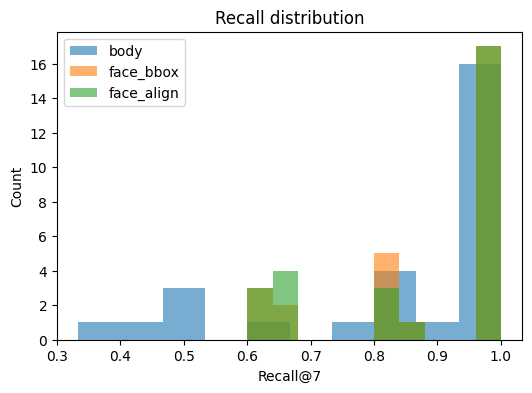

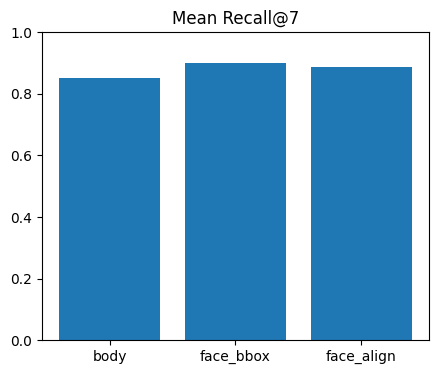

In [14]:
# Visualization: recall distribution and mean comparison
import matplotlib.pyplot as plt

def plot_recall_hist(df, label, top_k=24):
    if df.empty:
        print(f'No data for {label}')
        return
    plt.hist(df[f'recall@{top_k}'], bins=10, alpha=0.6, label=label)

plt.figure(figsize=(6,4))
plot_recall_hist(body_df, 'body', TOP_K)
plot_recall_hist(face_bbox_df, 'face_bbox', TOP_K)
plot_recall_hist(face_align_df, 'face_align', TOP_K)
plt.xlabel(f'Recall@{TOP_K}')
plt.ylabel('Count')
plt.title('Recall distribution')
plt.legend()
plt.show()

plt.figure(figsize=(5,4))
means = [
    body_df[f'recall@{TOP_K}'].mean() if not body_df.empty else 0,
    face_bbox_df[f'recall@{TOP_K}'].mean() if not face_bbox_df.empty else 0,
    face_align_df[f'recall@{TOP_K}'].mean() if not face_align_df.empty else 0,
]
plt.bar(['body', 'face_bbox', 'face_align'], means)
plt.ylim(0, 1)
plt.title(f'Mean Recall@{TOP_K}')
plt.show()
